In [176]:
import pandas as pd 
import numpy as np 
import os 
import scipy.stats as stats
import category_encoders as ce
import matplotlib.pyplot as plt 
plt.rc("font", size=14)
import math 
#import seaborn as sns
# sns.set(style="white")
# sns.set(style="whitegrid", color_codes=True)
import string
from sklearn.compose import make_column_selector 
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import scale
import warnings
warnings.filterwarnings("ignore")
import datetime
from collections import Counter
from IPython.display import clear_output
from sklearn import datasets, linear_model
from sklearn.model_selection import LeaveOneOut
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score 
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import rand_score
from sklearn.metrics import adjusted_mutual_info_score
from sklearn.metrics import mutual_info_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error,  r2_score, explained_variance_score, make_scorer
from sklearn.model_selection import LeaveOneOut, cross_val_score,KFold
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report
%matplotlib inline

In [177]:
df=pd.read_csv("cirrhosis.csv")
df

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,414,681,D,NaN,24472,F,NaN,NaN,NaN,N,1.2,NaN,2.96,NaN,NaN,NaN,NaN,174.0,10.9,3.0
414,415,1103,C,NaN,14245,F,NaN,NaN,NaN,N,0.9,NaN,3.83,NaN,NaN,NaN,NaN,180.0,11.2,4.0
415,416,1055,C,NaN,20819,F,NaN,NaN,NaN,N,1.6,NaN,3.42,NaN,NaN,NaN,NaN,143.0,9.9,3.0
416,417,691,C,NaN,21185,F,NaN,NaN,NaN,N,0.8,NaN,3.75,NaN,NaN,NaN,NaN,269.0,10.4,3.0


In [178]:
df.isnull().sum()

ID                 0
N_Days             0
Status             0
Drug             106
Age                0
Sex                0
Ascites          106
Hepatomegaly     106
Spiders          106
Edema              0
Bilirubin          0
Cholesterol      134
Albumin            0
Copper           108
Alk_Phos         106
SGOT             106
Tryglicerides    136
Platelets         11
Prothrombin        2
Stage              6
dtype: int64

<Axes: >

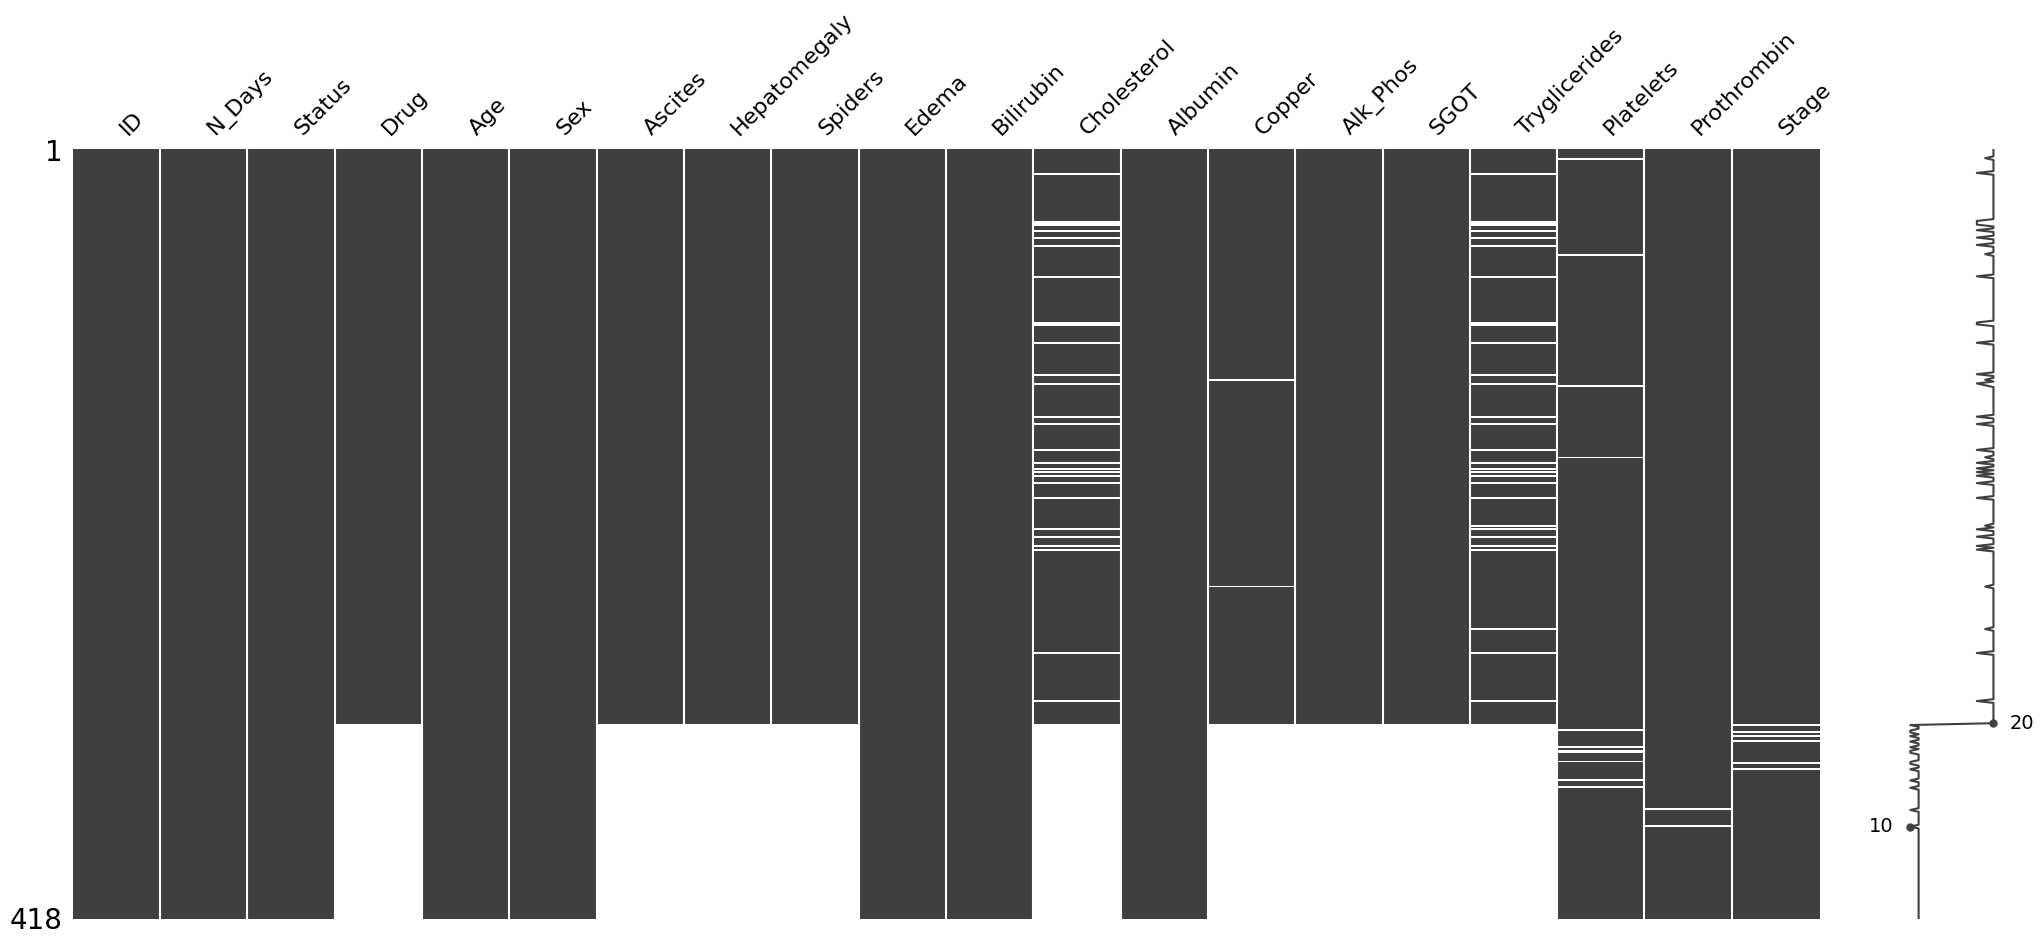

In [179]:
import missingno as msno 
msno.matrix(df)

In [180]:
df['missing_count'] = df.isnull().sum(axis=1)
df['missing_count'].unique()

array([ 0,  1,  2, 10,  9], dtype=int64)

<Axes: >

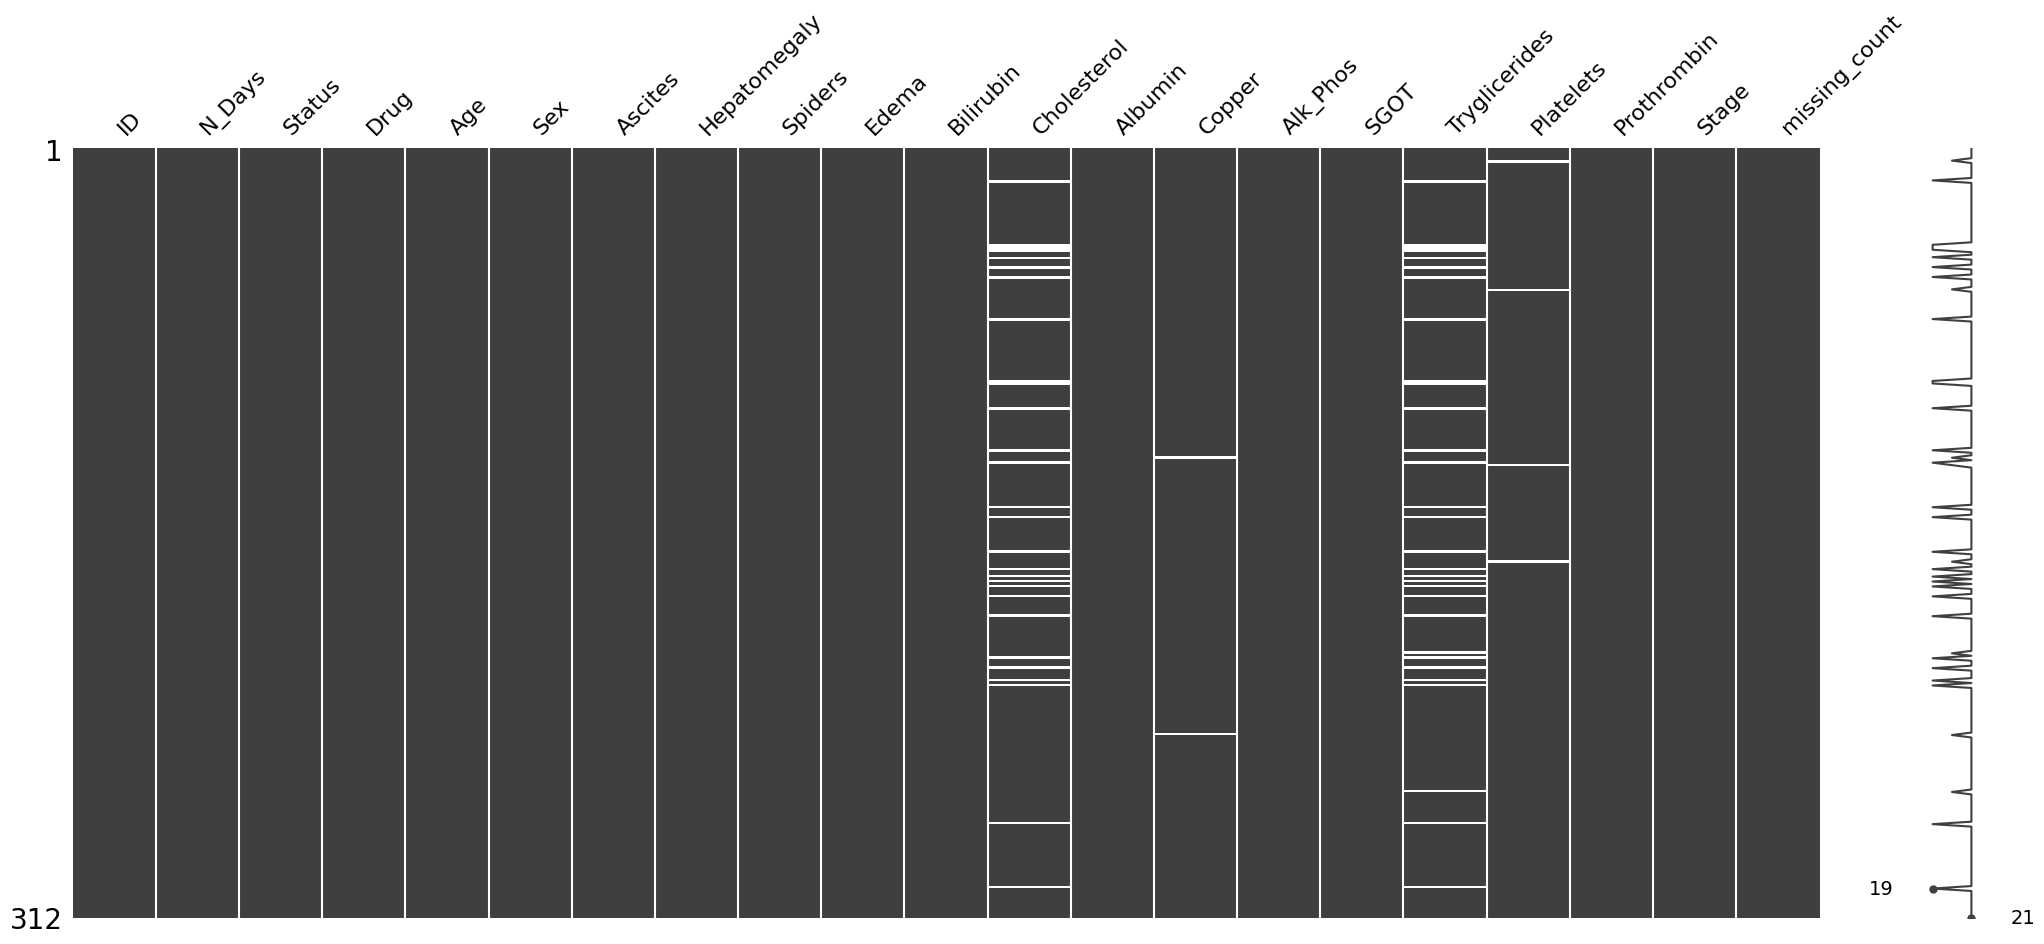

In [181]:
df_cleaned = df[df['missing_count']<9]
msno.matrix(df_cleaned)

In [182]:
del df['missing_count']

In [183]:
df.columns

Index(['ID', 'N_Days', 'Status', 'Drug', 'Age', 'Sex', 'Ascites',
       'Hepatomegaly', 'Spiders', 'Edema', 'Bilirubin', 'Cholesterol',
       'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets',
       'Prothrombin', 'Stage'],
      dtype='object')

In [184]:
del df['ID']

In [185]:
cat=[]
num=[]
for i in df.columns:
    if df[i].dtype=="object":
        cat.append(i)
    else:
        num.append(i)
print(cat) 
print(num) 

['Status', 'Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema']
['N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage']


In [186]:
import pickle

outlier_limits = {}

for col in num:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_limits[col] = (lower, upper)
    
outlier_limits

{'N_Days': (-1188.375, 4894.625),
 'Age': (7202.5, 29714.5),
 'Bilirubin': (-3.0999999999999996, 7.299999999999999),
 'Cholesterol': (23.75, 625.75),
 'Albumin': (2.4512500000000004, 4.561249999999999),
 'Copper': (-81.375, 245.625),
 'Alk_Phos': (-791.25, 3642.75),
 'SGOT': (-26.350000000000023, 258.85),
 'Tryglicerides': (-15.875, 251.125),
 'Platelets': (-5.75, 512.25),
 'Prothrombin': (8.350000000000001, 12.75),
 'Stage': (-1.0, 7.0)}

In [187]:
pickle.dump(outlier_limits, open("outlier_limits.pkl", "wb"))
outlier_limits = pickle.load(open("outlier_limits.pkl", "rb"))

In [188]:
from sklearn.impute import KNNImputer
knn_imputer = KNNImputer(n_neighbors=3)
df[num] = knn_imputer.fit_transform(df[num])
pickle.dump(knn_imputer, open("knn_imputer.pkl", "wb"))

In [189]:
from sklearn.impute import SimpleImputer
simple_imputer = SimpleImputer(strategy='most_frequent')
pickle.dump(simple_imputer, open("simple_imputer.pkl", "wb"))
df[cat] = simple_imputer.fit_transform(df[cat])

In [190]:
df

,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,400.0,D,D-penicillamine,21464.0,F,Y,Y,Y,Y,14.5,261.000000,2.60,156.000000,1718.000000,137.950000,172.000000,190.0,12.2,4.0
1,4500.0,C,D-penicillamine,20617.0,F,N,Y,Y,N,1.1,302.000000,4.14,54.000000,7394.800000,113.520000,88.000000,221.0,10.6,3.0
2,1012.0,D,D-penicillamine,25594.0,M,N,N,N,S,1.4,176.000000,3.48,210.000000,516.000000,96.100000,55.000000,151.0,12.0,4.0
3,1925.0,D,D-penicillamine,19994.0,F,N,Y,Y,S,1.8,244.000000,2.54,64.000000,6121.800000,60.630000,92.000000,183.0,10.3,4.0
4,1504.0,CL,Placebo,13918.0,F,N,Y,Y,N,3.4,279.000000,3.53,143.000000,671.000000,113.150000,72.000000,136.0,10.9,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,681.0,D,D-penicillamine,24472.0,F,N,Y,N,N,1.2,377.000000,2.96,195.000000,1424.000000,153.700000,157.333333,174.0,10.9,3.0
414,1103.0,C,D-penicillamine,14245.0,F,N,Y,N,N,0.9,390.000000,3.83,136.333333,3088.066667,95.843333,119.000000,180.0,11.2,4.0
415,1055.0,C,D-penicillamine,20819.0,F,N,Y,N,N,1.6,455.000000,3.42,90.000000,871.666667,96.333333,99.666667,143.0,9.9,3.0
416,691.0,C,D-penicillamine,21185.0,F,N,Y,N,N,0.8,484.333333,3.75,154.666667,1689.333333,123.050000,137.000000,269.0,10.4,3.0


In [191]:
for i in range (len(cat)):
    print(df[cat[i]].unique())

['D' 'C' 'CL']
['D-penicillamine' 'Placebo']
['F' 'M']
['Y' 'N']
['Y' 'N']
['Y' 'N']
['Y' 'N' 'S']


In [192]:
Target = "Status"

In [193]:
from sklearn.preprocessing import LabelEncoder
import pickle

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df[Target])
pickle.dump(label_encoder, open("indep_encoder.pkl", "wb"))

dep_encoders = {}

for col in cat:
    if col!=Target:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        dep_encoders[col] = le   # store encoder per column

# Save dictionary of encoders

pickle.dump(dep_encoders, open("dep_encoders.pkl", "wb"))

In [194]:
df

,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,400.0,D,0,21464.0,0,1,1,1,2,14.5,261.000000,2.60,156.000000,1718.000000,137.950000,172.000000,190.0,12.2,4.0
1,4500.0,C,0,20617.0,0,0,1,1,0,1.1,302.000000,4.14,54.000000,7394.800000,113.520000,88.000000,221.0,10.6,3.0
2,1012.0,D,0,25594.0,1,0,0,0,1,1.4,176.000000,3.48,210.000000,516.000000,96.100000,55.000000,151.0,12.0,4.0
3,1925.0,D,0,19994.0,0,0,1,1,1,1.8,244.000000,2.54,64.000000,6121.800000,60.630000,92.000000,183.0,10.3,4.0
4,1504.0,CL,1,13918.0,0,0,1,1,0,3.4,279.000000,3.53,143.000000,671.000000,113.150000,72.000000,136.0,10.9,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,681.0,D,0,24472.0,0,0,1,0,0,1.2,377.000000,2.96,195.000000,1424.000000,153.700000,157.333333,174.0,10.9,3.0
414,1103.0,C,0,14245.0,0,0,1,0,0,0.9,390.000000,3.83,136.333333,3088.066667,95.843333,119.000000,180.0,11.2,4.0
415,1055.0,C,0,20819.0,0,0,1,0,0,1.6,455.000000,3.42,90.000000,871.666667,96.333333,99.666667,143.0,9.9,3.0
416,691.0,C,0,21185.0,0,0,1,0,0,0.8,484.333333,3.75,154.666667,1689.333333,123.050000,137.000000,269.0,10.4,3.0


In [195]:
## DiVide the dataset into indepent and dependent features
X=df.drop(Target,axis=1)
y=y_encoded

## Split the data in training and tetsing sets
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [196]:
from sklearn.preprocessing import StandardScaler
## Scale these features
zscaler=StandardScaler()
X_train=zscaler.fit_transform(X_train)
X_test=zscaler.transform(X_test)


pickle.dump(zscaler, open("zscaler.pkl", "wb"))


In [197]:
# %pip install imblearn
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

In [198]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
LRM = LogisticRegression(max_iter=200,solver="liblinear",penalty='l1')

In [199]:
LRM.fit(X_train,y_train)
y_pred = LRM.predict(X_test)

In [200]:
pickle.dump(LRM, open("LRModel.pkl", "wb"))